In [1]:
#Sales data eda and forcasting- Suravi Poudel

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [3]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [6]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [7]:
df = df.drop_duplicates()

In [8]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')
df['Day'] = df['Order Date'].dt.day

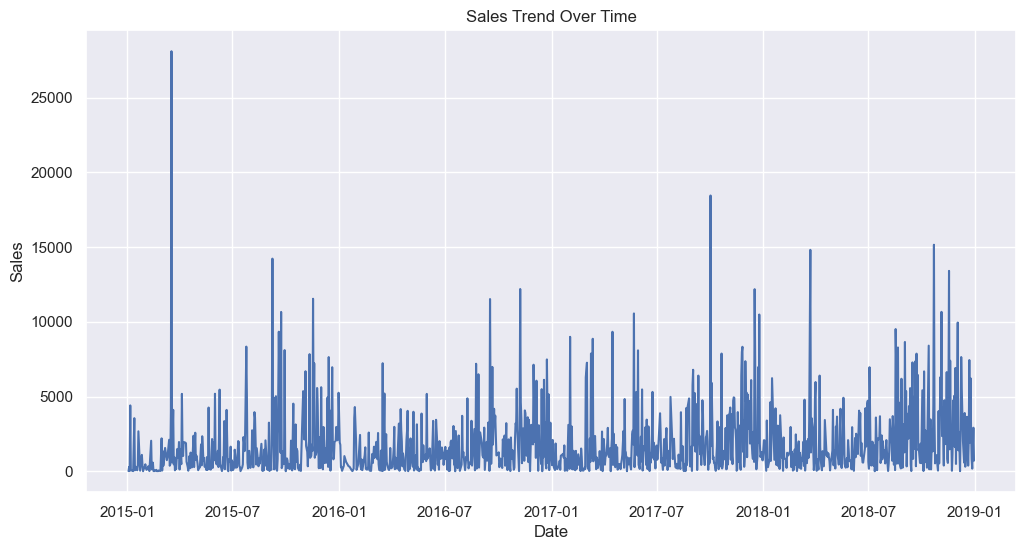

In [9]:
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12,6))
plt.plot(sales_trend)
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

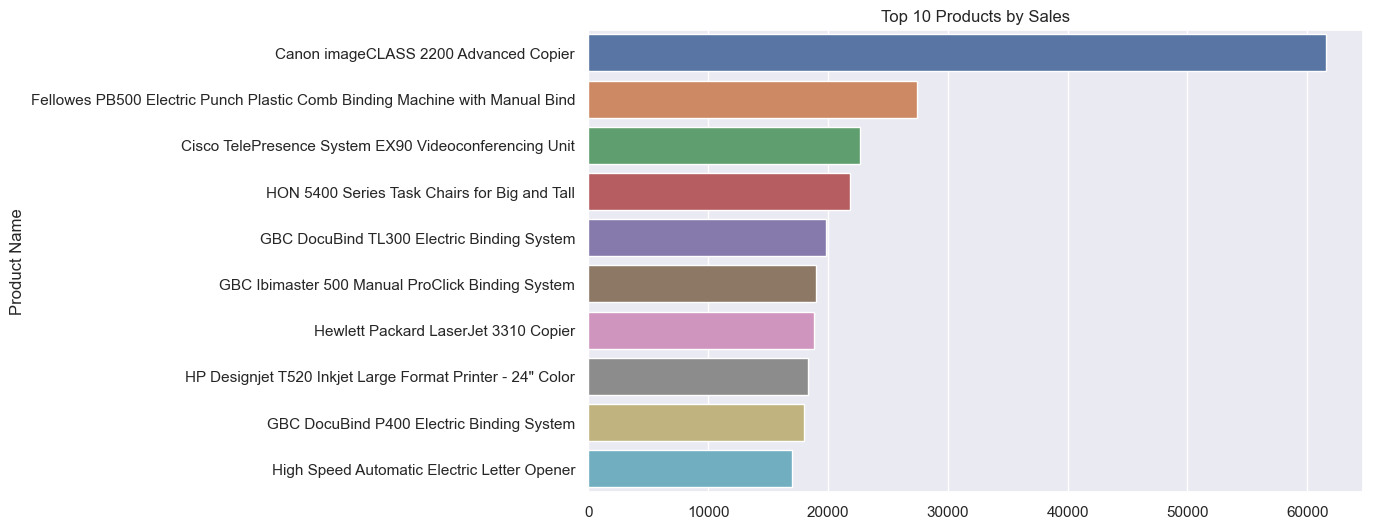

In [10]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.show()

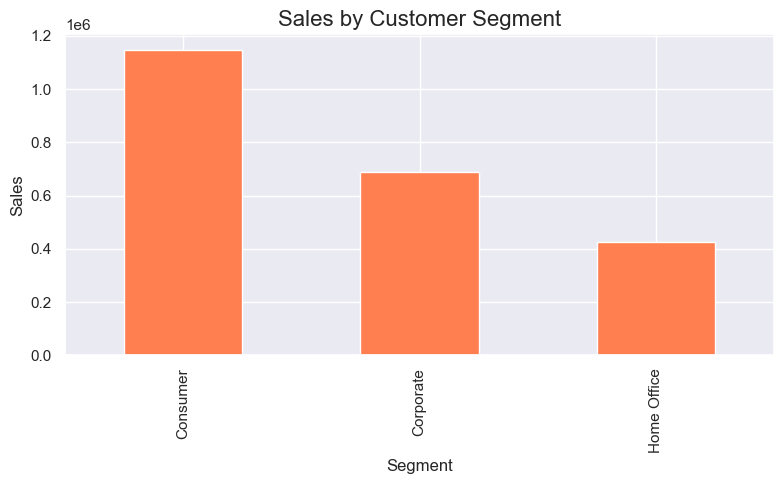

In [11]:
segment_sales = df.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar', color='coral')
plt.title("Sales by Customer Segment", fontsize=16)
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Sales", fontsize=12)
plt.tight_layout()
plt.show()

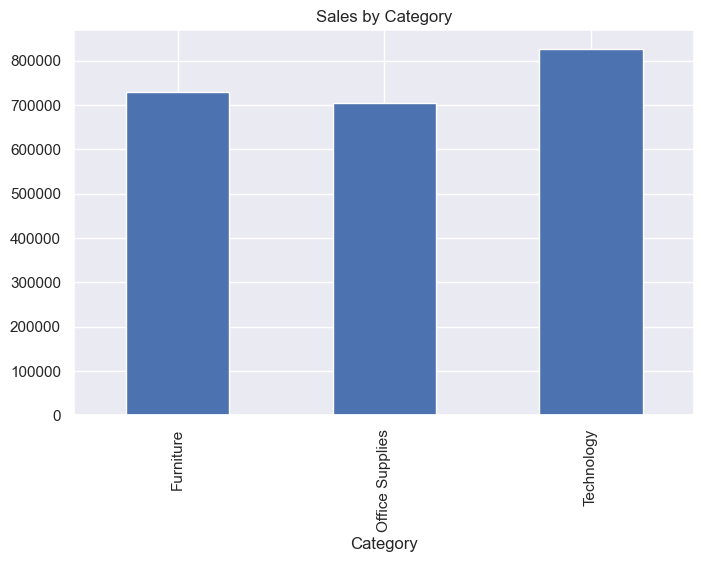

In [12]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.show()

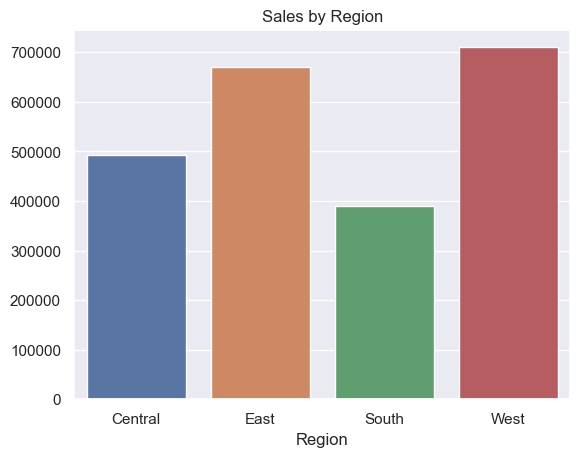

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.show()

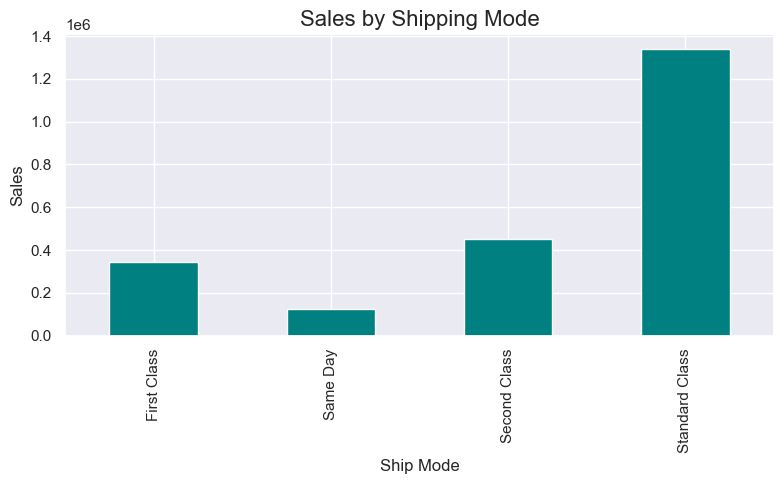

In [14]:
ship_sales = df.groupby('Ship Mode')['Sales'].sum()
plt.figure(figsize=(8,5))
ship_sales.plot(kind='bar', color='teal')
plt.title("Sales by Shipping Mode", fontsize=16)
plt.xlabel("Ship Mode", fontsize=12)
plt.ylabel("Sales", fontsize=12)
plt.tight_layout()
plt.show()

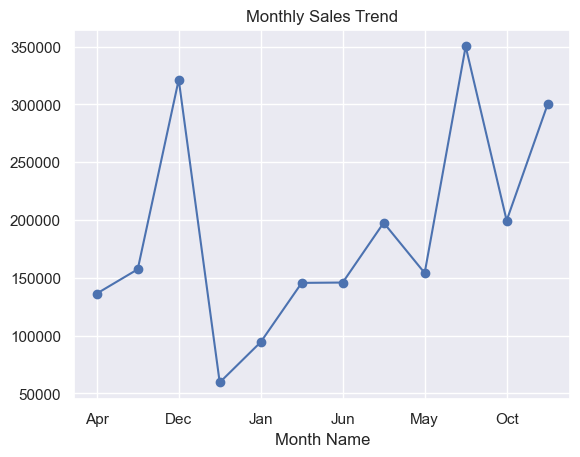

In [15]:
monthly_sales = df.groupby('Month Name')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

In [16]:
ts = df.groupby('Order Date')['Sales'].sum().reset_index()

ts.set_index('Order Date', inplace=True)

In [17]:
train = ts[:'2016']
test = ts['2017':]

In [18]:
from sklearn.linear_model import LinearRegression

# Create time index
ts['time'] = np.arange(len(ts))

train = ts.iloc[:int(len(ts)*0.8)]
test = ts.iloc[int(len(ts)*0.8):]

model = LinearRegression()
model.fit(train[['time']], train['Sales'])

predictions = model.predict(test[['time']])

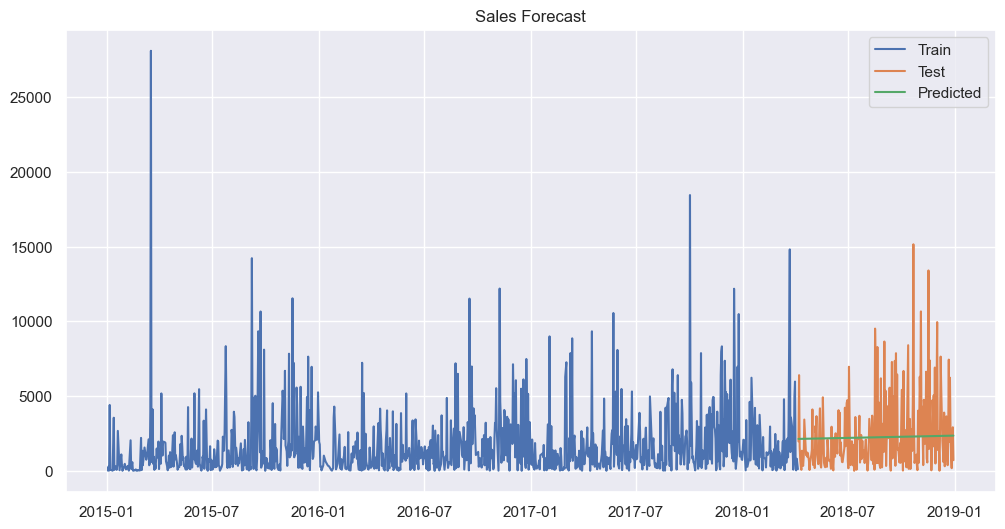

In [19]:
plt.figure(figsize=(12,6))
plt.plot(train['Sales'], label='Train')
plt.plot(test['Sales'], label='Test')
plt.plot(test.index, predictions, label='Predicted')
plt.legend()
plt.title("Sales Forecast")
plt.show()

In [20]:
ts = df.groupby('Order Date')['Sales'].sum().reset_index()
ts.set_index('Order Date', inplace=True)

ADF Statistic: -6.251366350804211
p-value: 4.4457704265948233e-08
Time series is stationary.


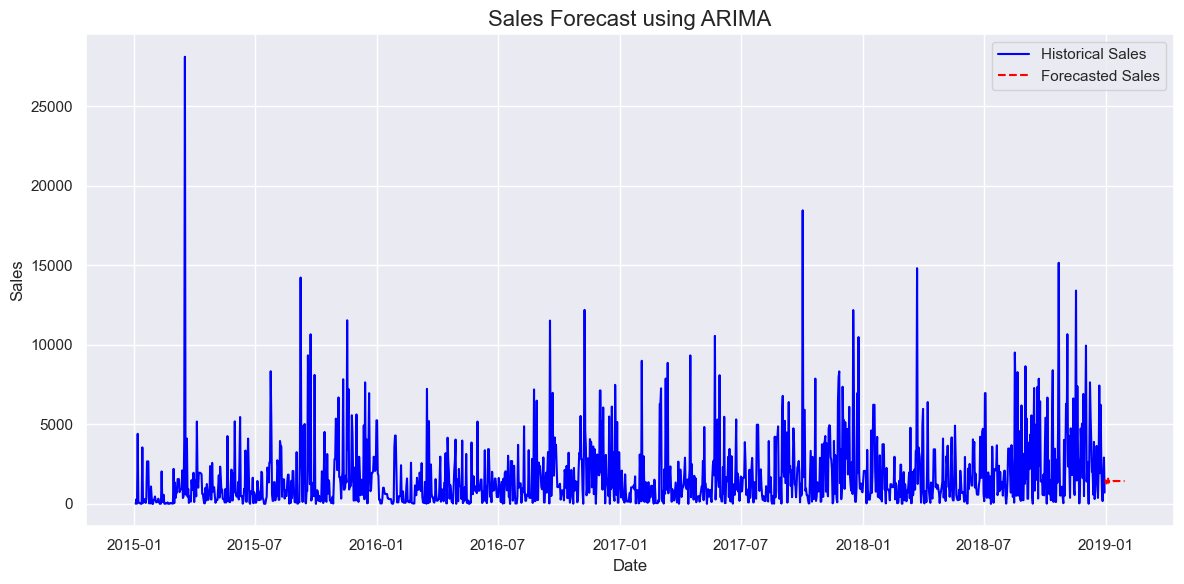

In [21]:
# -------------------------------
# Forecasting - ARIMA
# -------------------------------
 # 1. Libraries
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Suppress warnings
warnings.filterwarnings('ignore')

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Aggregate daily sales
ts = df.groupby('Order Date')['Sales'].sum()
ts = ts.asfreq('D')  # make it daily frequency, fills missing dates with NaN
ts = ts.fillna(method='ffill')  # forward fill missing sales

# 3. Check stationarity (ADF test)
result = adfuller(ts)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] < 0.05:
    print("Time series is stationary.")
else:
    print("Time series is non-stationary, differencing may be required.")

# 4. Fit ARIMA model
# Order (p,d,q) = (5,1,0) is a starting point
model = ARIMA(ts, order=(5,1,0))
model_fit = model.fit()

# 5. Forecast next 30 days
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# 6. Plot historical + forecast
plt.figure(figsize=(12,6))
plt.plot(ts, label='Historical Sales', color='blue')
plt.plot(forecast.index, forecast, label='Forecasted Sales', color='red', linestyle='--')
plt.title("Sales Forecast using ARIMA", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------
# Forecasting - Prophet
# -------------------------------

# 1. Libraries
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from prophet import Prophet

# Suppress warnings
warnings.filterwarnings('ignore')

# 2. Load dataset (make sure your CSV is in the same folder)
df = pd.read_csv("train.csv")

# 3. Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# 4. Aggregate daily sales
ts = df.groupby('Order Date')['Sales'].sum().reset_index()

# 5. Rename columns for Prophet
ts.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)

# 6. Initialize and fit Prophet model
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
model.fit(ts)

# 7. Create future dates (next 30 days)
future = model.make_future_dataframe(periods=30)

# 8. Forecast
forecast = model.predict(future)

# 9. Plot forecast (Historical + Predicted)
fig1 = model.plot(forecast, figsize=(14,7))
plt.title("Sales Forecast using Prophet", fontsize=18, weight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Sales", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 10. Plot components (Trend, Weekly, Yearly seasonality)
fig2 = model.plot_components(forecast, figsize=(14,10))
plt.tight_layout()
plt.show()
